In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load dataset
df = pd.read_csv('factory_data.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 9)


,Unique ID,Product ID,Quality,Ambient T (C),Process T (C),Rotation Speed (rpm),Torque (Nm),Tool Wear (min),Machine Status
0,1,K12965,M,24.95,35.45,1551.0,42.8,0,0
1,2,Z62710,L,25.05,35.55,1408.0,46.3,3,0
2,3,T20224,L,24.95,35.35,1498.0,49.4,5,0
3,4,Z33024,L,25.05,35.45,1433.0,39.5,7,0
4,5,Z52839,L,25.05,35.55,1408.0,40.0,9,0


In [3]:
print(df.columns)

Index(['Unique ID', 'Product ID', 'Quality', 'Ambient T (C)', 'Process T (C)',
       'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)',
       'Machine Status'],
      dtype='object')


In [4]:
# print("\nTarget variable distribution:")
print(df['Machine Status'].value_counts())
#since its only 2 possible outcomes other visualisations wouldn't be too useful.

Machine Status
0    19322
1      678
Name: count, dtype: int64


Target Variable: Machine Status

Features: Unique ID, Product ID, Quality, Ambient T(C), Process T(C), Rotation Speed(rpm), Torque(Nm), Tool Wear Time(min)

I chose to ignore Unique ID and Product ID as they dont affect the target variable, Machine Status.

Problem Type: Binary Classification
Predicting if Machine is WORKING-0 of FAULTY-1

Since the dataset is imbalanced (only 3.39% of the data has machine status - 1), the best way to compare the models is using f1-score.

In [5]:
#finding missing values
print("Missing values per column:\n", df.isnull().sum())
print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:
 Unique ID                  0
Product ID                 0
Quality                  991
Ambient T (C)              0
Process T (C)            400
Rotation Speed (rpm)    1188
Torque (Nm)                0
Tool Wear (min)            0
Machine Status             0
dtype: int64
Number of duplicate rows: 0


In [6]:
df_cleaned = df.drop(['Unique ID', 'Product ID'], axis=1)
#seperating features and target
X = df_cleaned.drop('Machine Status', axis=1) #feature
y = df_cleaned['Machine Status'] #target variable

print("Feature types:")
#check type of features
print(X.dtypes)

Feature types:
Quality                  object
Ambient T (C)           float64
Process T (C)           float64
Rotation Speed (rpm)    float64
Torque (Nm)             float64
Tool Wear (min)           int64
dtype: object


In [7]:
#impute missing values
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
#for numerical columns, impute with median
print(numerical_cols)

for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())
    print(col, X[col].median())

#for categorical columns, imput with mode (most frequent value)
X['Quality']=X['Quality'].fillna(X['Quality'].mode()[0])
print('Quality', X['Quality'].mode()[0])

#check if there's still any more missing values
print("Missing values after imputation:\n", X.isnull().sum())

Index(['Ambient T (C)', 'Process T (C)', 'Rotation Speed (rpm)', 'Torque (Nm)',
       'Tool Wear (min)'],
      dtype='object')
Ambient T (C) 26.95
Process T (C) 36.95
Rotation Speed (rpm) 1503.0
Torque (Nm) 40.1
Tool Wear (min) 108.0
Quality L
Missing values after imputation:
 Quality                 0
Ambient T (C)           0
Process T (C)           0
Rotation Speed (rpm)    0
Torque (Nm)             0
Tool Wear (min)         0
dtype: int64


In [8]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X_encoded = pd.get_dummies(X, columns=['Quality'], drop_first=True)
#convert quality into numeric columns
#scale numerical features
scaler = StandardScaler()
numerical_cols = ['Ambient T (C)', 'Process T (C)', 'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)']
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])
X_encoded.head()

,Ambient T (C),Process T (C),Rotation Speed (rpm),Torque (Nm),Tool Wear (min),Quality_L,Quality_M
0,-0.977082,-0.990803,0.082604,0.282200,-1.695984,False,True
1,-0.927102,-0.922716,-0.741656,0.633308,-1.648852,True,False
2,-0.977082,-1.058890,-0.222891,0.944290,-1.617430,True,False
3,-0.927102,-0.990803,-0.597555,-0.048845,-1.586009,True,False
4,-0.927102,-0.922716,-0.741656,0.001313,-1.554588,True,False


In [9]:
#train test split!!
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#split such that 20% of data goes into test data and 80% goes into train data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
#LOGISTIC REGRESSION
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

#fit into model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
scores_log = cross_val_score(lr_model, X_train, y_train, cv=5)
print("Cross-validation scores:", scores_log)
print("Average accuracy:", scores_log.mean())
#predict values for the test set
y_pred = lr_model.predict(X_test)

#evaluation of model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Cross-validation scores: [0.9696875 0.969375  0.96875   0.9690625 0.9703125]
Average accuracy: 0.9694375000000001
Accuracy: 0.9715

Confusion Matrix:
 [[3858    6]
 [ 108   28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3864
           1       0.82      0.21      0.33       136

    accuracy                           0.97      4000
   macro avg       0.90      0.60      0.66      4000
weighted avg       0.97      0.97      0.96      4000



EVALUATION:

from the classification report, we can conclude that the accuracy was high (97%) but the F1-score for faulty machines(1) was low(0.33).

In [11]:
#RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5)
print("Random Forest Cross-validation scores:", scores_rf)
print("Random Forest Average accuracy:", scores_rf.mean())


y_pred = rf_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Cross-validation scores: [0.9909375 0.9884375 0.9896875 0.9884375 0.9925   ]
Random Forest Average accuracy: 0.99
Accuracy: 0.992

Confusion Matrix:
 [[3864    0]
 [  32  104]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3864
           1       1.00      0.76      0.87       136

    accuracy                           0.99      4000
   macro avg       1.00      0.88      0.93      4000
weighted avg       0.99      0.99      0.99      4000



EVALUATION:

from the classification report, we can conclude that the accuracy was high (99%) and the F1-score for faulty machines(1) was also high(0.87).

In [12]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
scores_knn = cross_val_score(knn_model, X_train, y_train, cv=5)
print("kNN Cross-validation scores:", scores_knn)
print("kNN Average accuracy:", scores_knn.mean())

y_pred = knn_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

kNN Cross-validation scores: [0.9765625 0.976875  0.974375  0.975625  0.9778125]
kNN Average accuracy: 0.97625
Accuracy: 0.9805

Confusion Matrix:
 [[3856    8]
 [  70   66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3864
           1       0.89      0.49      0.63       136

    accuracy                           0.98      4000
   macro avg       0.94      0.74      0.81      4000
weighted avg       0.98      0.98      0.98      4000



EVALUATION:

from the classification report, we can conclude that the accuracy was high (98%) but the F1-score for faulty machines(1) was moderately good(0.63).

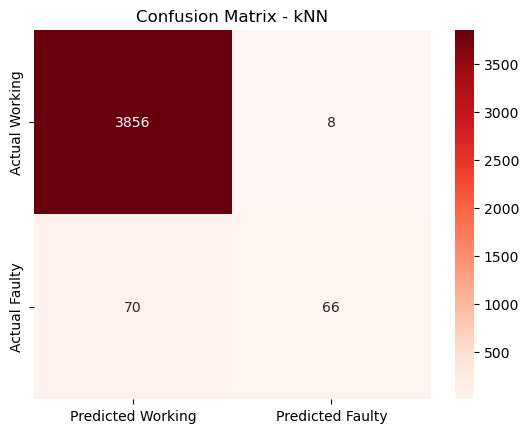

In [13]:
cm = [[3856, 8],
      [70, 66]]
import seaborn as sns

cm_df = pd.DataFrame(cm, index=['Actual Working','Actual Faulty'],
                     columns=['Predicted Working','Predicted Faulty'])

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - kNN")
plt.show()

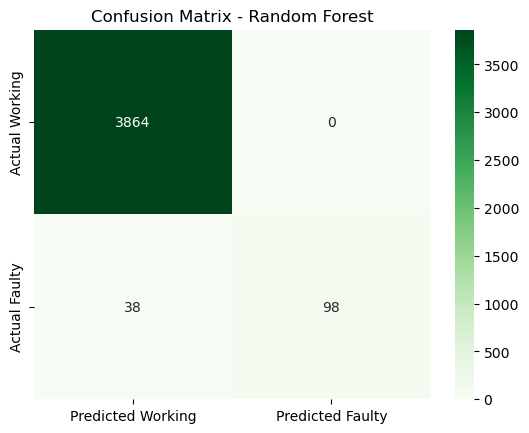

In [14]:
cm = [[3864, 0],
      [38, 98]]

cm_df = pd.DataFrame(cm, index=['Actual Working','Actual Faulty'],
                     columns=['Predicted Working','Predicted Faulty'])

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

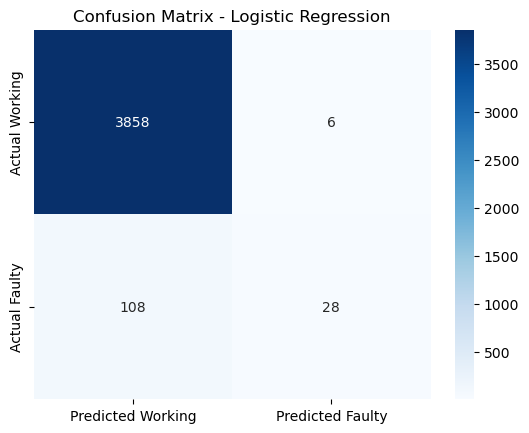

In [15]:
cm = [[3858, 6],
      [108, 28]]

cm_df = pd.DataFrame(cm, index=['Actual Working','Actual Faulty'],
                     columns=['Predicted Working','Predicted Faulty'])

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

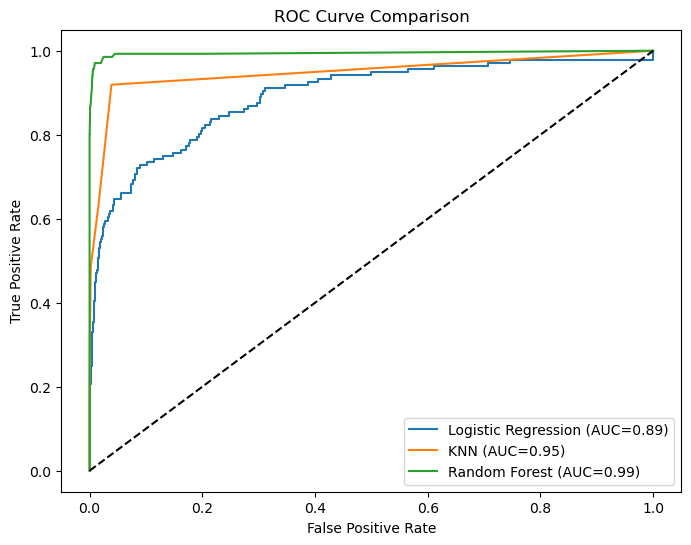

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {'Logistic Regression': lr_model,
          'KNN': knn_model,
          'Random Forest': rf_model}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

EVALUATION:

Random Forest has the highest number of true positive leading to a higher AUC score.

In [17]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='constant', constant = 1)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

f1_score_dummy = f1_score(y_test, y_pred_dummy)

print("DUMMY BASELINE RESULTS:")
print("F1-SCORE:", f1_score_dummy)
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))

NameError: name 'f1_score' is not defined

[0.32941176470588235, 0.6285714285714286, 0.8666666666666667, 0.06576402321083172]


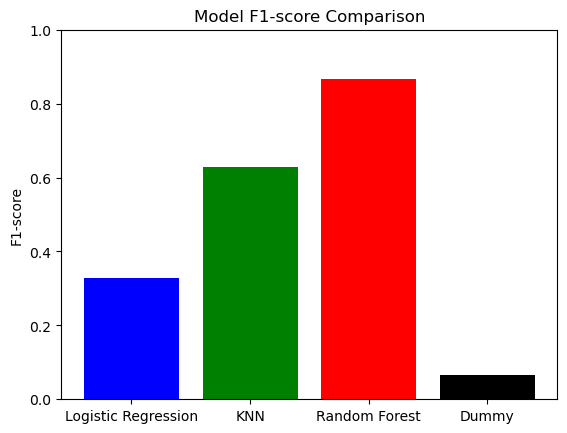

In [18]:
from sklearn.metrics import f1_score

f1_scores = [
    f1_score(y_test, lr_model.predict(X_test)),
    f1_score(y_test, knn_model.predict(X_test)),
    f1_score(y_test, rf_model.predict(X_test)),
    f1_score(y_test, dummy.predict(X_test))
]
print (f1_scores)
plt.bar(['Logistic Regression','KNN','Random Forest', 'Dummy'], f1_scores, color=['blue','green','red', 'black'])
plt.ylabel("F1-score")
plt.title("Model F1-score Comparison")
plt.ylim(0,1)
plt.show()

EVALUATION:

Random Forest has the highest F1-score. This shows that Random Forest is the best model to use in this scenario.

In [19]:
# random forest hyperparameter tuning:
# randomisedsearchcv

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score)

# Define parameter distributions
param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [5, 10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy']
}
rf_random = RandomForestClassifier(random_state=42, n_jobs=-1)


start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='f1',  # Optimize for f1-score
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

random_search.fit(X_train, y_train)
random_time = time.time() - start_time


# Evaluate on test set
y_pred_random = random_search.predict(X_test)
y_pred_proba_random = random_search.predict_proba(X_test)[:, 1]
best_model = random_search.best_estimator_
print('Best Model:', best_model)

print("Test Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_random):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_random):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_random):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_random):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_random):.4f}\n")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


EVALUATION:

- F1-score has improved from 0.8667 to 0.8689

- ROC-AUC score also improved from 0.99 to 0.9977

- The best model is using a balanced class_weight. This makes sense because the dataset is skewed (only above 3% of the data is faulty machines).

In [ ]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title("Random Forest Feature Importance")
plt.show()

This barchart shows that Torque is the most important feature that influences the machine status (target variable), then followed by Rotation Speed & Tool Wear.

In [ ]:
#distribution of most important feature by target variable
import seaborn as sns
sns.boxplot(x=df_cleaned['Machine Status'], y=df_cleaned['Torque (Nm)'], data=df)
plt.title("Torque Distribution by Machine Status")
plt.show()

This Boxplot shows that the higher the Torque value, the more likely the machine is faulty.

In [ ]:
sns.boxplot(x=df_cleaned['Machine Status'], y=df_cleaned['Rotation Speed (rpm)'], data=df)
plt.title("Rotation Speed Distribution by Machine Status")
plt.show()

sns.boxplot(x=df_cleaned['Machine Status'], y=df_cleaned['Tool Wear (min)'], data=df)
plt.title("Tool Wear Distribution by Machine Status")
plt.show()

#distribution of machine status -- rotation speed & tool wear 

The Rotation Speed Distribution by Machine Status Boxplot shows that the lower the rotation speed is, the more likely the machine is faulty.

The Tool Wear Distribution by Machine Status Boxplot shows that the higher the tool wear, the more likely the machine is faulty